In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import exp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import scale
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import csv

## Setup
Getting info and exploring the data

In [69]:
filename = 'mini-itc-data.csv'

df = pd.read_csv(filename)
print('done reading')

df.info()
df.head()

# combine same regions
region_map = {
    'africa-south1': 'africa-south',
    'ap-northeast1': 'ap-northeast',
    'ap-northeast2': 'ap-northeast',
    'ap-south1': 'ap-south',
    'ap-south2': 'ap-south',
    'ap-southeast1': 'ap-southeast',
    'ap-southeast2': 'ap-southeast',
    'asia-east1': 'asia-east',
    'asia-south1': 'asia-south',
    'ca-central1': 'ca-central',
    'eu-central1': 'eu-central',
    'eu-central2': 'eu-central',
    'eu-north1': 'eu-north',
    'eu-west1' : 'eu-west',
    'eu-west2' : 'eu-west',
    'latam-north1': 'latam-north',
    'latam-south1': 'latam-south',
    'latam-south2': 'latam-south',
    'me-central1': 'me-central',
    'us-central1': 'us-central',
    'us-central2': 'us-central',
    'us-east1': 'us-east',
    'us-east2': 'us-east',
    'us-east3': 'us-east',
    'us-west1': 'us-west',
    'us-west2': 'us-west'
}

done reading
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   system_name                    100 non-null    object 
 1   region                         100 non-null    object 
 2   attack_type                    100 non-null    object 
 3   data_sensitivity_level         100 non-null    int64  
 4   records_exposed                100 non-null    int64  
 5   estimated_cost_per_record_usd  100 non-null    float64
 6   estimated_total_cost_usd       100 non-null    float64
 7   detection_delay_days           100 non-null    int64  
 8   response_time_days             100 non-null    int64  
 9   notification_required          100 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 7.9+ KB


# Cleaning
## Sort by region


In [80]:


# Group by region and system, summing total cost
region_system_costs = (
    df.groupby(['region', 'system_name'])['estimated_total_cost_usd']
        .sum()
        .reset_index()
)

# Pivot so each system_name becomes its own column
region_summary = (
    region_system_costs
    .pivot(index='region', columns='system_name', values='estimated_total_cost_usd')
    .fillna(0)
)

# Add total per region
region_summary['total_region_damage_usd'] = region_summary.sum(axis=1)
region_summary = region_summary.reset_index()

print(region_summary)

system_name         region  Analytics     Billing         CRM          HR  \
0            africa-south1  181017.35  1041940.92        0.00        0.00   
1            ap-northeast1  110760.18  2471140.33    70718.62  1542276.81   
2            ap-northeast2   76645.42  1359560.59   666793.10  1229052.56   
3                ap-south1  193859.47  2460599.64   495641.02   580770.87   
4                ap-south2  214079.82   897015.02  1046776.65        0.00   
5            ap-southeast1   12777.50   834231.62   539272.62        0.00   
6            ap-southeast2       0.00   725999.77  1354231.41        0.00   
7               asia-east1  185213.85   960009.70   379421.01   610034.65   
8              asia-south1       0.00   892759.36        0.00        0.00   
9              ca-central1   90380.92   504431.92  1769502.68   813476.32   
10             eu-central1  243686.07  1153098.19        0.00   809799.88   
11             eu-central2   38762.46   389056.90  1279696.38        0.00   

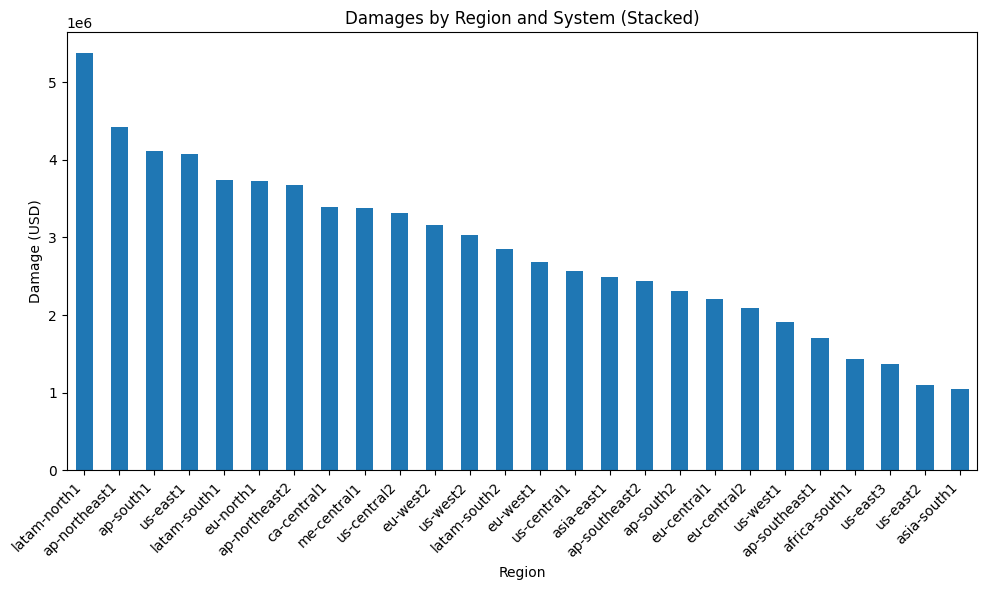

In [81]:
#plot graph of total region damage
ax = region_summary
ax = ax.set_index('region')
ax = ax.sort_values('total_region_damage_usd', ascending=False)

ax = ax['total_region_damage_usd'].plot(
    kind='bar',
    figsize=(10, 6)
)
ax.set_xlabel('Region')
ax.set_ylabel('Damage (USD)')
ax.set_title('Damages by Region and System (Stacked)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

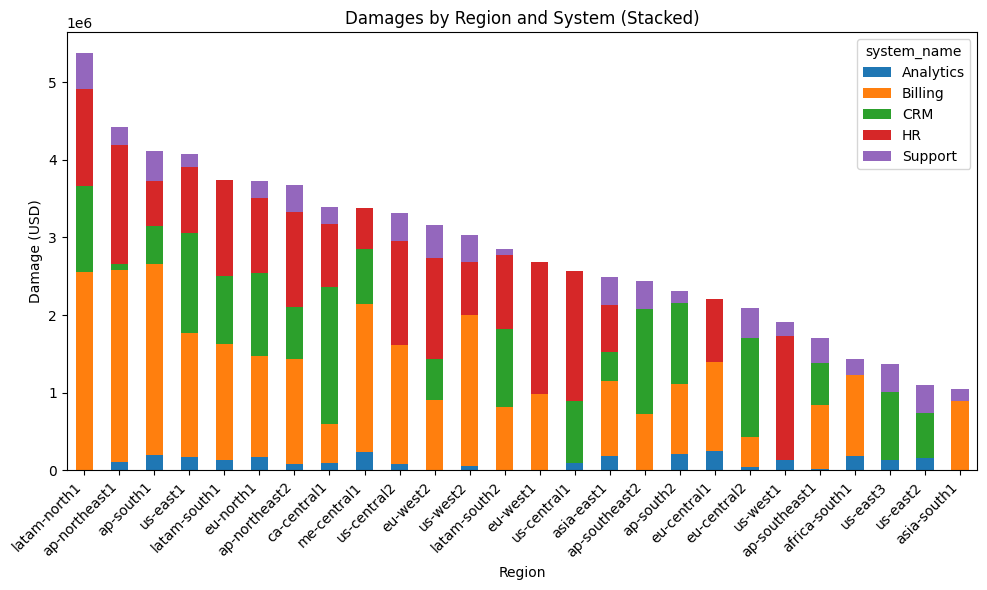

In [82]:
#plot graph
ax = region_summary
ax = ax.set_index('region')
ax = ax.sort_values('total_region_damage_usd', ascending=False)

ax = ax.drop(columns='total_region_damage_usd').plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)
ax.set_xlabel('Region')
ax.set_ylabel('Damage (USD)')
ax.set_title('Damages by Region and System (Stacked)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

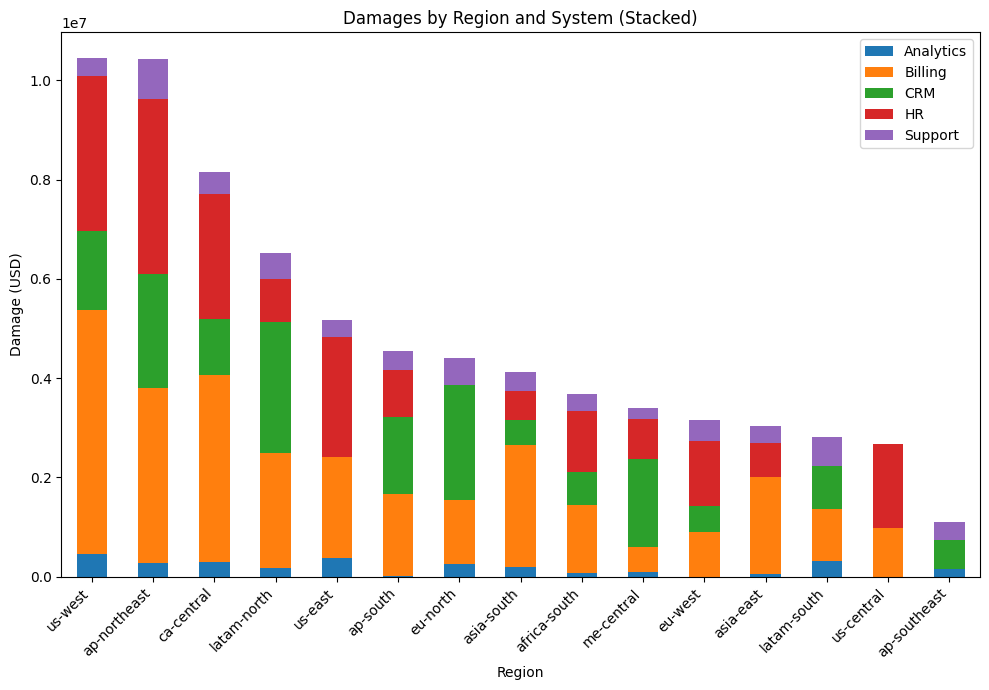

In [83]:
# merge regions
region_summary = region_summary.copy()
region_summary.columns.name = None

region_merged = (
    region_summary.assign(region=df['region'].replace(region_map))
      .groupby('region', as_index=False)
      .sum(numeric_only=True)     # sums Analytics/Billing/CRM/HR, etc.
)

#plot graph
ax = region_merged
ax = ax.set_index('region')
ax = ax.sort_values('total_region_damage_usd', ascending=False)

ax = ax.drop(columns='total_region_damage_usd').plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7)
)
ax.set_xlabel('Region')
ax.set_ylabel('Damage (USD)')
ax.set_title('Damages by Region and System (Stacked)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Sort by system

In [ ]:
#combine money lost and average time it took to respond (detection + response)
df['total_response_time'] = df['detection_delay_days'] + df['response_time_days']

systems_df = df.groupby('system_name').agg(
    total_cost_usd=('estimated_total_cost_usd', 'sum'),
    avg_response_time_days=('total_response_time', 'mean')
).reset_index()

print(systems_df)

  system_name  total_cost_usd  avg_response_time_days
0   Analytics      2716835.05               16.400000
1     Billing     28724234.86               20.090909
2         CRM     16456266.25               20.368421
3          HR     19668537.43               20.777778
4     Support      6050008.76               17.190476


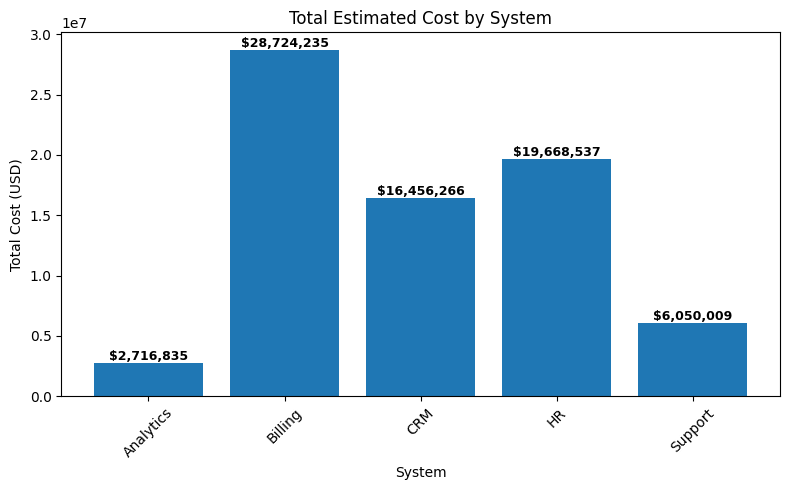

In [91]:
#graph 1: Total money lost per system
plt.figure(figsize=(8,5))
bars1 = plt.bar(systems_df['system_name'], systems_df['total_cost_usd'])
plt.title('Total Estimated Cost by System')
plt.xlabel('System')
plt.ylabel('Total Cost (USD)')
plt.xticks(rotation=45)

#add value labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"${yval:,.0f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

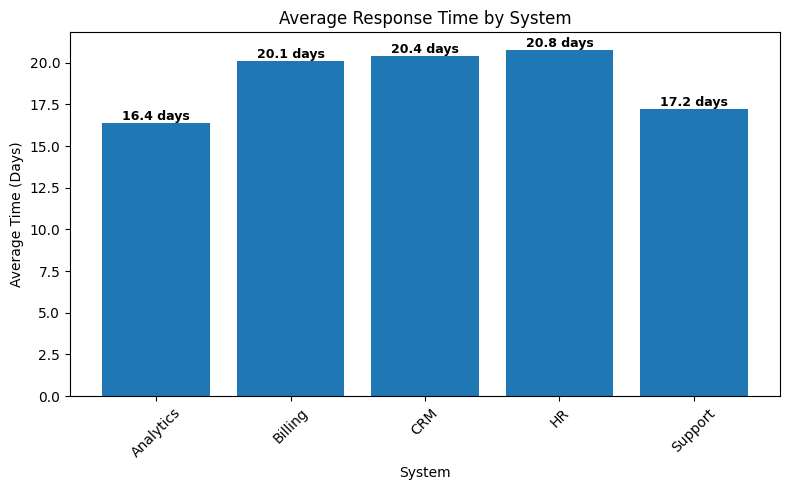

In [92]:
#graph average response time per system
plt.figure(figsize=(8,5))
bars2 = plt.bar(systems_df['system_name'], systems_df['avg_response_time_days'])
plt.title('Average Response Time by System')
plt.xlabel('System')
plt.ylabel('Average Time (Days)')
plt.xticks(rotation=45)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.1f} days", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Sort by average money lost weighted by days it took to respond

In [84]:
# response time
rt = df['response_time_days'].astype(float)
dd = df['detection_delay_days'].astype(float)
raw = 0.5*rt + 0.5*dd

w = 1 + 2 * (raw - raw.min()) / (raw.max() - raw.min() if raw.max()>raw.min() else 1.0)

df = df.copy()
df['weighted_damage_usd'] = df['estimated_total_cost_usd'] * w

#sum weighted damages by region and system
region_system_weighted = (
    df.groupby(['region', 'system_name'], as_index=False)['weighted_damage_usd']
        .sum()
)

#pivot 
weighted_by_region = (
    region_system_weighted
    .pivot(index='region', columns='system_name', values='weighted_damage_usd')
    .fillna(0)
)

#add total
weighted_by_region['total_weighted_region_damage_usd'] = weighted_by_region.sum(axis=1)

weighted_by_region = (
    weighted_by_region
        .sort_values('total_weighted_region_damage_usd', ascending=False)
        .reset_index()
)

print(weighted_by_region.head())





system_name         region      Analytics       Billing           CRM  \
0             latam-north1       0.000000  4.748380e+06  2.066217e+06   
1                 us-east1  212594.605000  3.423906e+06  3.862210e+06   
2                ap-south1  318483.415000  5.975742e+06  7.080586e+05   
3            ap-northeast1  221520.360000  4.942281e+06  1.868992e+05   
4             latam-south1  238783.907143  4.167048e+06  1.380668e+06   

system_name            HR        Support  total_weighted_region_damage_usd  
0            2.302000e+06  896270.920714                      1.001287e+07  
1            2.059848e+06  312223.971429                      9.870783e+06  
2            1.037091e+06  715057.664286                      8.754433e+06  
3            2.643903e+06  427714.912857                      8.422318e+06  
4            1.864022e+06       0.000000                      7.650521e+06  


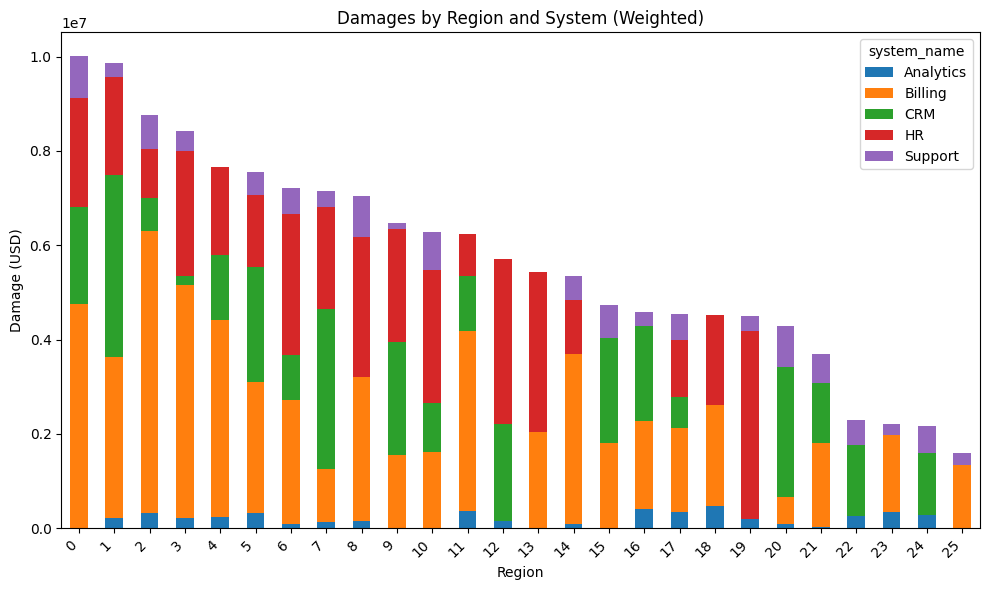

In [85]:
#plot

ax = weighted_by_region
ax = ax.drop(columns='total_weighted_region_damage_usd').plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)
ax.set_xlabel('Region')
ax.set_ylabel('Damage (USD)')
ax.set_title('Damages by Region and System (Weighted)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()